In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml


# set directory to parent directory
os.chdir("/Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae")

# print current working directory
print("Current Working Directory:", os.getcwd())

from utils.data_utils import get_data, get_gen

Current Working Directory: /Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae


In [4]:
dataset = "cifar10/"


In [5]:
ddpm_samples_path = '../from_cluster/results/' + dataset + 'seed_1/ddpm/sample/'
ddpm_reconstructions_path = '../from_cluster/results/' + dataset + 'seed_1/ddpm/recons/'

vae_samples_path = '../from_cluster/results/' + dataset + 'seed_1/vae/sample/'
vae_reconstructions_path = '../from_cluster/results/' + dataset + 'seed_1/vae/recons/'

In [6]:
# vae image files: "output_vae__{rank}_{batch_idx}.png"}"
# ddpm image files: "output_{rank}_{batch_idx}.png"}"

# get number of different batches
num_batch = 0
for filename in os.listdir(vae_samples_path):
    if filename.startswith("output_vae__"):
        cur_batch = int(filename.split("_")[4])
        if cur_batch > num_batch:
            num_batch = cur_batch

# get number of samples per batch
max_batch_idx = 0
for filename in os.listdir(vae_samples_path):
    if filename.startswith("output_vae__"):
        batch_idx = int(filename.split("_")[5].split(".")[0])
        if batch_idx > max_batch_idx:
            max_batch_idx = batch_idx

# CIFAR-10 Samples

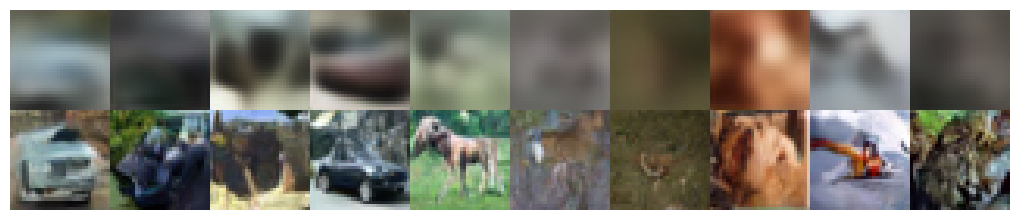

In [7]:
# create figure with 10 rows and 2 columns, no space between subplots and no axis
# top row: VAE samples
# bottom row: DDPM samples


fig = plt.figure(figsize=(10, 2))
fig.subplots_adjust(hspace=0, wspace=0)

# no space outside of figure and no axis
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)


# use first batch
for batch in range(1):
    # use first 10 samples
    for batch_idx in range(10):
        vae_filename = f"output_vae__0_{batch}_{batch_idx}.png"
        ddpm_filename = f"output__0_{batch}_{batch_idx}.png"

        # add vae sample to figure, top row and col=batch_idx
        vae_sample = mpimg.imread(vae_samples_path + vae_filename)
        ax = fig.add_subplot(2, 10, batch_idx + 1)
        ax.axis('off')
        ax.imshow(vae_sample)

        # add ddpm sample to figure, bottom row and col=batch_idx
        ddpm_sample = mpimg.imread(ddpm_samples_path + ddpm_filename)
        ax = fig.add_subplot(2, 10, batch_idx + 11)
        ax.axis('off')
        ax.imshow(ddpm_sample)
 
    

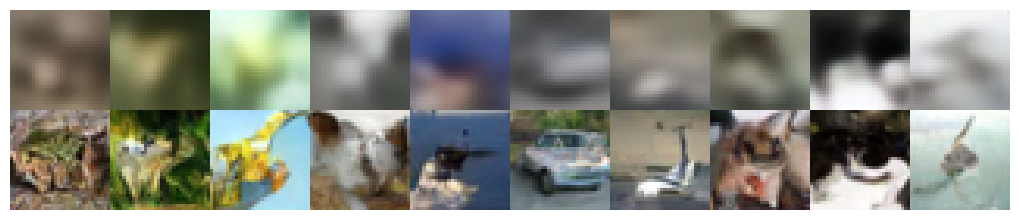

In [8]:
fig = plt.figure(figsize=(10, 2))  # Adjust figure size for 4 rows
fig.subplots_adjust(hspace=0, wspace=0)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# no space outside of figure and no axis
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# use second batch
for batch in range(1, 2):
    # use first 10 samples
    for batch_idx in range(10):
        vae_filename = f"output_vae__0_{batch}_{batch_idx}.png"
        ddpm_filename = f"output__0_{batch}_{batch_idx}.png"

        # add vae sample to figure, top row and col=batch_idx
        vae_sample = mpimg.imread(vae_samples_path + vae_filename)
        ax = fig.add_subplot(2, 10, batch_idx + 1)
        ax.axis('off')
        ax.imshow(vae_sample)

        # add ddpm sample to figure, bottom row and col=batch_idx
        ddpm_sample = mpimg.imread(ddpm_samples_path + ddpm_filename)
        ax = fig.add_subplot(2, 10, batch_idx + 11)
        ax.axis('off')
        ax.imshow(ddpm_sample)


# CIFAR-10 Reconstructions

In [11]:
dataset = 'cifar10/'

# use config of some trained cifar10 model to load data correctly
ex_name = '20240307-195731_9e95e'

path = '/Users/jorgegoncalves/Desktop/Repositories/Master_Thesis/treevae/models/experiments/'
checkpoint_path = path+dataset+ex_name
with open(checkpoint_path + "/config.yaml", 'r') as stream:
    configs = yaml.load(stream,Loader=yaml.Loader)

# load data
trainset, trainset_eval, testset = get_data(configs)
gen_train = get_gen(trainset, configs, validation=False, shuffle=False)
gen_train_eval = get_gen(trainset_eval, configs, validation=True, shuffle=False)
gen_test = get_gen(testset, configs, validation=True, shuffle=False)
gen_train_eval_iter = iter(gen_train_eval)
gen_test_iter = iter(gen_test)
y_train = trainset_eval.dataset.targets.clone().detach()[trainset_eval.indices].numpy()
y_test = testset.dataset.targets.clone().detach()[testset.indices].numpy()


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


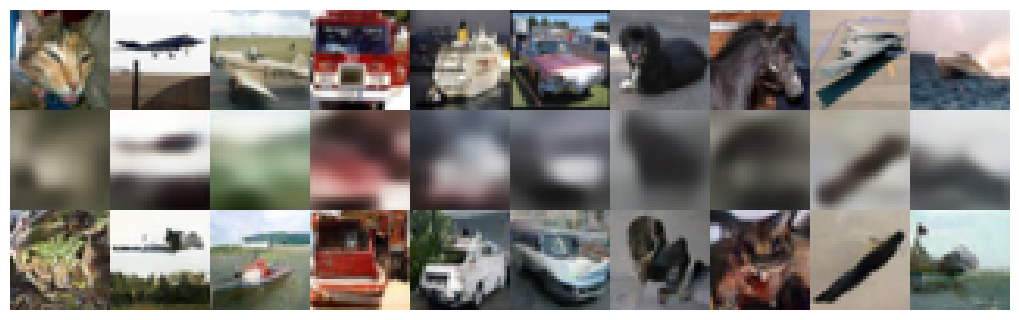

In [12]:
fig = plt.figure(figsize=(10, 3))
fig.subplots_adjust(hspace=0, wspace=0)

# no space outside of figure and no axis
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)


# use second batch
for batch in range(1, 2):
    # use first 10 samples
    for batch_idx in range(10):
        vae_filename = f"output_vae__0_{batch}_{batch_idx}.png"
        ddpm_filename = f"output__0_{batch}_{batch_idx}.png"

        index = batch * 256 + batch_idx
        # add image to top row
        # get batch_idx-th sample batch
        orig_img = testset.dataset.data[index]
        ax = fig.add_subplot(3, 10, batch_idx + 1)
        ax.axis('off')
        ax.imshow(orig_img)

        # add vae sample to figure, top row and col=batch_idx
        vae_sample = mpimg.imread(vae_reconstructions_path + vae_filename)
        ax = fig.add_subplot(3, 10, batch_idx + 11)
        ax.axis('off')
        ax.imshow(vae_sample)

        # add ddpm sample to figure, bottom row and col=batch_idx
        ddpm_sample = mpimg.imread(ddpm_reconstructions_path + ddpm_filename)
        ax = fig.add_subplot(3, 10, batch_idx + 21)
        ax.axis('off')
        ax.imshow(ddpm_sample)
 

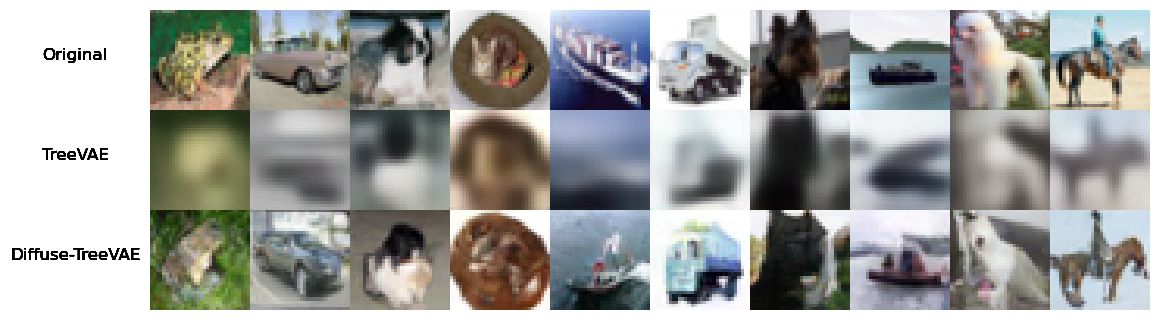

In [30]:
fig = plt.figure(figsize=(10, 3))
fig.subplots_adjust(hspace=0, wspace=0)

# no space outside of figure and no axis
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)


# use second batch
for batch in range(2, 3):
    # use first 10 samples
    for batch_idx in range(10):
        vae_filename = f"output_vae__0_{batch}_{batch_idx}.png"
        ddpm_filename = f"output__0_{batch}_{batch_idx}.png"

        index = batch * 256 + batch_idx
        # add image to top row
        # get batch_idx-th sample batch
        orig_img = testset.dataset.data[index]
        ax = fig.add_subplot(3, 10, batch_idx + 1)
        ax.axis('off')
        ax.imshow(orig_img)

        # add vae sample to figure, top row and col=batch_idx
        vae_sample = mpimg.imread(vae_reconstructions_path + vae_filename)
        ax = fig.add_subplot(3, 10, batch_idx + 11)
        ax.axis('off')
        ax.imshow(vae_sample)

        # add ddpm sample to figure, bottom row and col=batch_idx
        ddpm_sample = mpimg.imread(ddpm_reconstructions_path + ddpm_filename)
        ax = fig.add_subplot(3, 10, batch_idx + 21)
        ax.axis('off')
        ax.imshow(ddpm_sample)

        # add names of models for each row at left side of figure
        ax = fig.add_subplot(3, 10, 1)
        ax.axis('off')
        ax.text(-0.75, 0.5, "Original", fontsize=10, ha='center')
        ax = fig.add_subplot(3, 10, 11)
        ax.axis('off')
        ax.text(-0.75, 0.5, "TreeVAE", fontsize=10, ha='center')
        ax = fig.add_subplot(3, 10, 21)
        ax.axis('off')
        ax.text(-0.75, 0.5, "Diffuse-TreeVAE", fontsize=10, ha='center')

plt.show()
        



# CIFAR-10 Recons


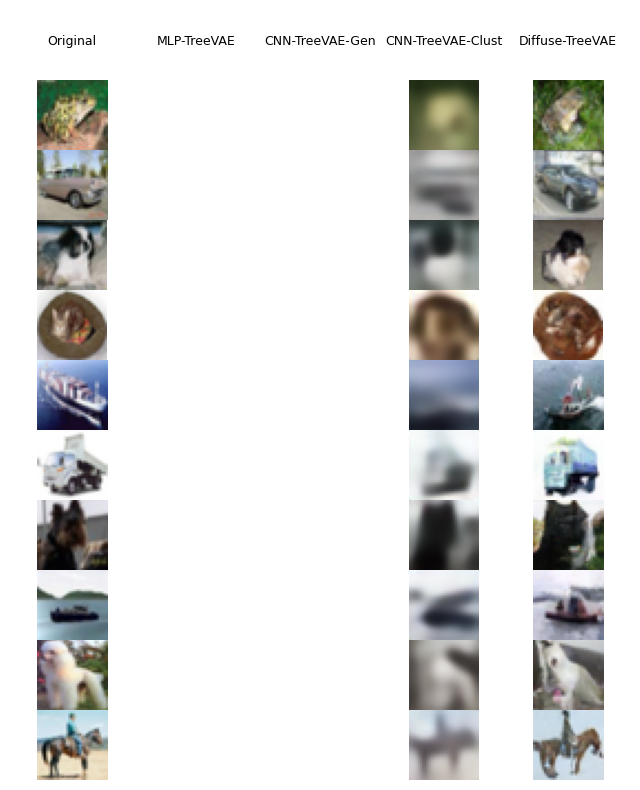

In [109]:
# create figure with 10 rows and 5 columns

# first column: original images
# second column: MLP-TreeVAE reconstructions
# third column: CNN-TreeVAE-Gen reconstructions
# fourth column: CNN-TreeVAE-Clust reconstructions
# fifth column: Diffuse-TreeVAE reconstructions

names = ['Original', 'MLP-TreeVAE', 'CNN-TreeVAE-Gen', 'CNN-TreeVAE-Clust', 'Diffuse-TreeVAE']

fig = plt.figure(figsize=(8, 10))
fig.subplots_adjust(hspace=0, wspace=0)

# add names to first row above each column
for i in range(5):
    ax = fig.add_subplot(11, 5, i+1)
    ax.axis('off')
    ax.text(0.5, 0.5, names[i], fontsize=9, ha='center')


# use second batch
for batch in range(2, 3):
    # use first 10 samples
    for batch_idx in range(10):
        # add original image to first column
        index = batch * 256 + batch_idx
        orig_img = testset.dataset.data[index]
        ax = fig.add_subplot(11, 5, 5*(batch_idx + 1) + 1)
        ax.axis('off')
        ax.imshow(orig_img)

        # add MLP-TreeVAE reconstruction to figure, second column
        # add placeholder for now, empty image


        # add CNN-TreeVAE-Clust (=vae) and Diffuse-TreeVAE (=ddpm) reconstruction to figure, fourth column 
        vae_filename = f"output_vae__0_{batch}_{batch_idx}.png"
        vae_sample = mpimg.imread(vae_reconstructions_path + vae_filename)
        ax = fig.add_subplot(11, 5, 5*(batch_idx + 1) + 4)
        ax.axis('off')
        ax.imshow(vae_sample)

        ddpm_filename = f"output__0_{batch}_{batch_idx}.png"
        ddpm_sample = mpimg.imread(ddpm_reconstructions_path + ddpm_filename)
        ax = fig.add_subplot(11, 5, 5*(batch_idx + 1) + 5)
        ax.axis('off')
        ax.imshow(ddpm_sample)





# CIFAR-10 Samples

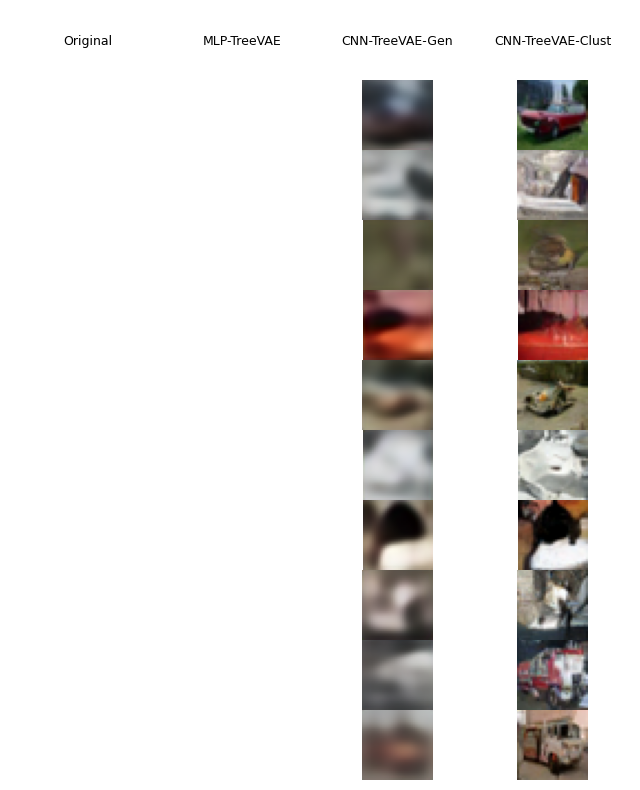

In [115]:

# create figure with 10 rows and 5 columns

# first column: original images
# second column: MLP-TreeVAE reconstructions
# third column: CNN-TreeVAE-Gen reconstructions
# fourth column: CNN-TreeVAE-Clust reconstructions
# fifth column: Diffuse-TreeVAE reconstructions

names = ['Original', 'MLP-TreeVAE', 'CNN-TreeVAE-Gen', 'CNN-TreeVAE-Clust', 'Diffuse-TreeVAE']

fig = plt.figure(figsize=(8, 10))
fig.subplots_adjust(hspace=0, wspace=0)

# add names to first row above each column
for i in range(4):
    ax = fig.add_subplot(11, 4, i+1)
    ax.axis('off')
    ax.text(0.5, 0.5, names[i], fontsize=9, ha='center')


# use second batch
for batch in range(3, 4):
    # use first 10 samples
    for batch_idx in range(10):

        # add MLP-TreeVAE reconstruction to figure, second column
        


        # add CNN-TreeVAE-Clust (=vae) and Diffuse-TreeVAE (=ddpm) reconstruction to figure, fourth column 
        vae_filename = f"output_vae__0_{batch}_{batch_idx}.png"
        vae_sample = mpimg.imread(vae_samples_path + vae_filename)
        ax = fig.add_subplot(11, 4, 4*(batch_idx + 1) + 3)
        ax.axis('off')
        ax.imshow(vae_sample)

        ddpm_filename = f"output__0_{batch}_{batch_idx}.png"
        ddpm_sample = mpimg.imread(ddpm_samples_path + ddpm_filename)
        ax = fig.add_subplot(11, 4, 4*(batch_idx + 1) + 4)
        ax.axis('off')
        ax.imshow(ddpm_sample)



